TOPOLOGICAL SATURATION: FROM SINGULARITY TO HORIZON SHELL

✓ Saved: topological_saturation.png


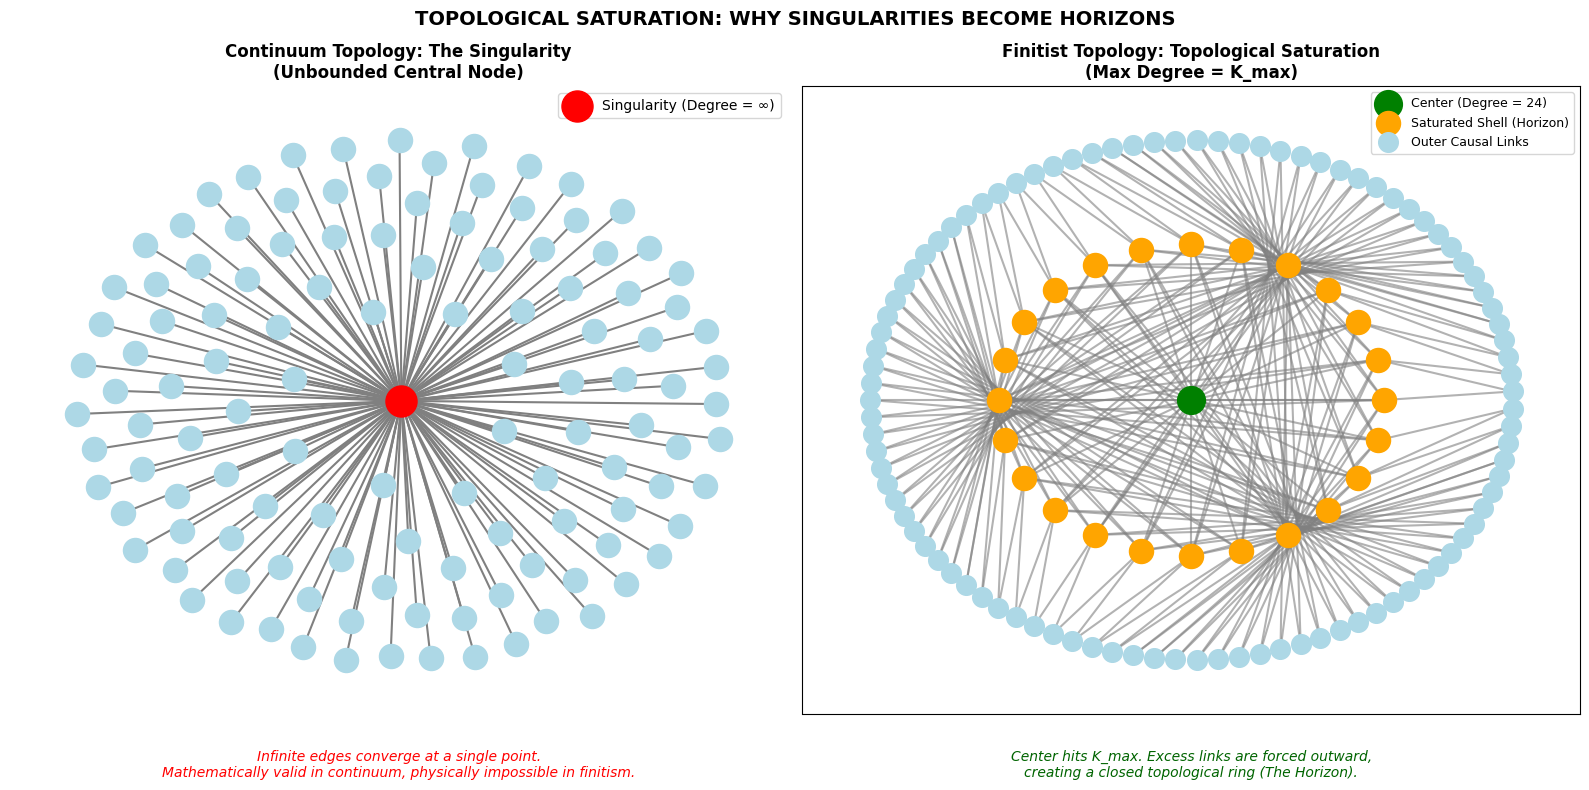


TOPOLOGICAL ANALYSIS
• Maximum Voxel Capacity (K_max): 24
• Nodes successfully connected to center: 24
• Nodes forced into the outer shell: 95
• CONCLUSION: A finite-degree graph CANNOT support a central singularity.
  It MUST undergo Topological Saturation, forming a closed boundary.


In [4]:
"""
topological_saturation.py
==========================
Simulating Topological Saturation in a Discrete Causal Graph.
Demonstrates how a maximum degree constraint (K_max) forces a topological
transition from a central singularity (Star Graph) to a saturated shell (Ring Graph).

Author: Néstor E. Ramos
For: "The Pixelated Universe" - Topology of the Finite Substrate
"""

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("TOPOLOGICAL SATURATION: FROM SINGULARITY TO HORIZON SHELL")
print("=" * 70)

# =============================================================================
# PARAMETERS
# =============================================================================
# K_max represents the maximum causal capacity (connectivity) of a single Planck voxel.
# In our framework, this is bounded by the finite alphabet (d_max = 9).
# We use 6 here for clear visual symmetry, but the math holds for any finite K_max.
K_MAX = 24
N_NODES = 120  # Total nodes trying to connect to the center

# =============================================================================
# GRAPH GENERATION
# =============================================================================

def generate_saturated_graph(n_nodes, k_max):
    """
    Attempts to connect all nodes to a central node (node 0).
    Enforces a hard maximum degree (k_max) on the central node.
    Excess connections are forced to route to the outer ring.
    """
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))

    center = 0
    current_degree = 0

    # 1. Fill the center up to its maximum capacity (The "Sub-Saturated" Phase)
    for i in range(1, n_nodes):
        if current_degree < k_max:
            G.add_edge(center, i)
            current_degree += 1
        else:
            break # Center is saturated

    # 2. Handle the "Overflow" (The "Topological Saturation" Phase)
    # The remaining nodes cannot connect to the center.
    # To maintain causal connectivity, they must connect to the already-connected nodes,
    # forming a topological ring (a horizon).
    saturated_nodes = list(range(1, current_degree + 1))
    overflow_nodes = list(range(current_degree + 1, n_nodes))

    # Connect overflow nodes to the saturated shell to form a cycle/ring
    for i in range(len(overflow_nodes)):
        # Connect to the nearest node in the saturated shell
        shell_node = saturated_nodes[i % len(saturated_nodes)]
        G.add_edge(overflow_nodes[i], shell_node)

        # Connect to the next node in the shell to close the topological loop
        next_shell_node = saturated_nodes[(i + 1) % len(saturated_nodes)]
        if not G.has_edge(overflow_nodes[i], next_shell_node):
            G.add_edge(overflow_nodes[i], next_shell_node)

    return G, current_degree, len(overflow_nodes)

# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_topological_saturation():
    G, connected, overflow = generate_saturated_graph(N_NODES, K_MAX)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    # --- Left Plot: The Continuum Ideal (Unbounded Star Graph) ---
    G_star = nx.star_graph(N_NODES - 1)
    pos_star = nx.spring_layout(G_star, seed=42)

    ax1.set_title("Continuum Topology: The Singularity\n(Unbounded Central Node)",
                  fontsize=12, fontweight='bold')
    nx.draw(G_star, pos_star, ax=ax1, node_color='lightblue',
            node_size=300, edge_color='gray', width=1.5)
    # Highlight the "Singularity"
    nx.draw_networkx_nodes(G_star, pos_star, nodelist=[0], ax=ax1,
                           node_color='red', node_size=500, label='Singularity (Degree = ∞)')
    ax1.legend(fontsize=10)
    ax1.text(0.5, -0.1, "Infinite edges converge at a single point.\nMathematically valid in continuum, physically impossible in finitism.",
             transform=ax1.transAxes, ha='center', fontsize=10, style='italic', color='red')

    # --- Right Plot: The Finitist Reality (Topologically Saturated Shell) ---
    # Custom layout to clearly show the center and the saturated ring
    pos_fin = {}
    pos_fin[0] = np.array([0, 0]) # Center

    # Place the saturated shell in a circle
    shell_nodes = list(range(1, connected + 1))
    for i, node in enumerate(shell_nodes):
        angle = 2 * np.pi * i / len(shell_nodes)
        pos_fin[node] = np.array([np.cos(angle), np.sin(angle)]) * 1.5

    # Place overflow nodes slightly further out
    overflow_nodes = list(range(connected + 1, N_NODES))
    for i, node in enumerate(overflow_nodes):
        angle = 2 * np.pi * (i + 0.5) / len(overflow_nodes)
        pos_fin[node] = np.array([np.cos(angle), np.sin(angle)]) * 2.5

    ax2.set_title("Finitist Topology: Topological Saturation\n(Max Degree = K_max)",
                  fontsize=12, fontweight='bold')

    # Draw edges
    nx.draw_networkx_edges(G, pos_fin, ax=ax2, edge_color='gray', width=1.5, alpha=0.6)

    # Draw nodes with specific colors for the topology
    nx.draw_networkx_nodes(G, pos_fin, nodelist=[0], ax=ax2,
                           node_color='green', node_size=400, label=f'Center (Degree = {K_MAX})')
    nx.draw_networkx_nodes(G, pos_fin, nodelist=shell_nodes, ax=ax2,
                           node_color='orange', node_size=300, label='Saturated Shell (Horizon)')
    nx.draw_networkx_nodes(G, pos_fin, nodelist=overflow_nodes, ax=ax2,
                           node_color='lightblue', node_size=200, label='Outer Causal Links')

    ax2.legend(fontsize=9, loc='upper right')
    ax2.text(0.5, -0.1, "Center hits K_max. Excess links are forced outward,\ncreating a closed topological ring (The Horizon).",
             transform=ax2.transAxes, ha='center', fontsize=10, style='italic', color='darkgreen')

    plt.suptitle("TOPOLOGICAL SATURATION: WHY SINGULARITIES BECOME HORIZONS",
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()

    fig.savefig("topological_saturation.png", dpi=300, bbox_inches='tight')
    print("\n✓ Saved: topological_saturation.png")
    plt.show()

    print("\n" + "=" * 70)
    print("TOPOLOGICAL ANALYSIS")
    print("=" * 70)
    print(f"• Maximum Voxel Capacity (K_max): {K_MAX}")
    print(f"• Nodes successfully connected to center: {connected}")
    print(f"• Nodes forced into the outer shell: {overflow}")
    print("• CONCLUSION: A finite-degree graph CANNOT support a central singularity.")
    print("  It MUST undergo Topological Saturation, forming a closed boundary.")
    print("=" * 70)

if __name__ == "__main__":
    plot_topological_saturation()